In [2]:
import pandas as pd
import numpy as np
import pandas_ta as ta
from pandas_ta.volatility import kc 

df = pd.read_csv("../data/MSFT.USUSD_Candlestick_5_M_BID_01.09.2022-21.09.2024.csv")
df=df[df['Volume']!=0]
df["Gmt time"]=df["Gmt time"].str.replace(".000","")
df['Gmt time']=pd.to_datetime(df['Gmt time'],format='%d.%m.%Y %H:%M:%S')
df['ema25'] = df['Close'].ewm(span=25, adjust=False).mean()

df.reset_index(drop=True, inplace=True)
df=df[df.High!=df.Low]

df=df[0:2000]

# Bolinger Bands
df.ta.bbands(append=True, length=20, std=2)

# Initialize Keltner Channel Indictor
kc=kc(high=df['High'], low=df['Low'], close=df["Close"], window=20)

#Bolinger Band Upper - Keltner Channel Upper
df['bbu_minus_kcu'] = df['BBU_20_2.0'] - kc['KCUe_20_2']

pd.options.mode.copy_on_write = True

In [3]:
def detectSqueeze(candle):

    isSqueeze = 0
    if (df.iloc[candle]).bbu_minus_kcu<=0:
        isSqueeze = 1
            
    return isSqueeze  

df['squeeze'] = df.apply(lambda row: detectSqueeze(row.name), axis=1)

In [34]:
def detectPosibleBreak(candle):

    levelBreak = 0
    ema25 = (df.iloc[candle]).ema25
    close = (df.iloc[candle]).Close 

    squeeze = (df.iloc[candle])['squeeze']
    if squeeze==1:
        high = (df.iloc[candle]).High
        if (abs(high-ema25) <= .20)& (close<ema25):
            levelBreak = 2
            
        low = (df.iloc[candle]).Low
        if (abs(low-ema25) <= .20) & (close>ema25):
            levelBreak = 1
            
    return levelBreak

df['posibleBreak'] = df.apply(lambda row: detectPosibleBreak(row.name), axis=1)

In [35]:
def entryArea(x):
    if (x['posibleBreak']==1):
        return x['Low']-.50
    elif (x['posibleBreak']==2):
        return x['High']+.50 
    else:
        return np.nan
        
df['entryArea'] = df.apply(lambda row: entryArea(row), axis=1)

In [36]:
def squezzeArea(x):
    if (x['squeeze']==1) & (x['Close']>x['ema25']):
        return x['Low']-.50
    elif (x['squeeze']==1) & (x['Close']<x['ema25']):
        return x['High']+.50 
    else:
        return np.nan
        
df['squezzeArea'] = df.apply(lambda row: squezzeArea(row), axis=1)
#df.to_csv('squezze.csv', index=False)

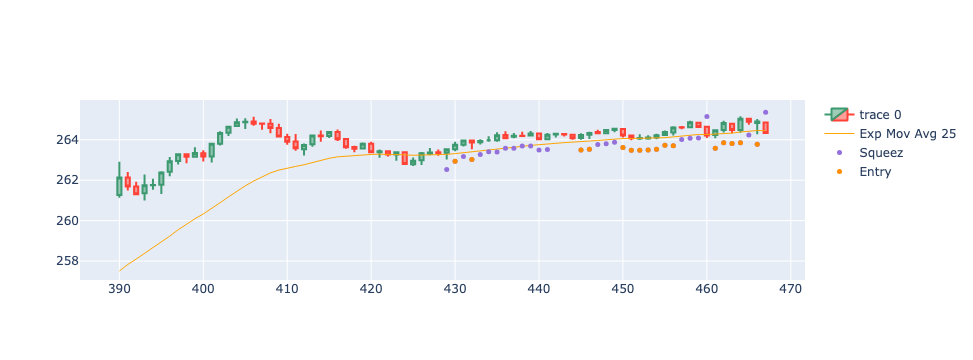

In [39]:
import plotly.io as pio
import plotly.graph_objects as go  
import numpy as np

'''
0:78
78:156
156:234
234:312 *
312:390 *
390:468
468:546
546:624
624:702
702:780
780:858
858:936
936:1014
1014:1092
1092:1170
1170:1248
1248:1326
1326:1404
1404:1482
1482:1560
1560:1638
1638:1716
1716:1794
1794:1872
1872:1950
1950:2028
2028:2106
'''
dfpl = df[390:468]

fig = go.Figure(data=[
                    go.Candlestick(x=dfpl.index,
                                    open=dfpl['Open'],
                                    high=dfpl['High'],
                                    low=dfpl['Low'],
                                    close=dfpl['Close']),
                    go.Scatter(x=dfpl.index, y=dfpl['ema25'], line=dict(color='orange', width=1), name="Exp Mov Avg 25")
                ])

fig.add_scatter(x=dfpl.index, y=dfpl['squezzeArea'], mode="markers", marker=dict(size=5, color="MediumPurple"), name="Squeez")
fig.add_scatter(x=dfpl.index, y=dfpl['entryArea'], mode="markers", marker=dict(size=5, color="darkorange"), name="Entry")

fig.update_layout(xaxis_rangeslider_visible=False)
fig.show()